# Week 3: Robust SEP Probe

## Improvements Over Basic SEP

1. **Layer Ensemble**: Combine predictions from layers 8, 10, 16
2. **MLP Probe**: Non-linear probe for better pattern capture
3. **More Test Examples**: 50+ OOD examples across diverse languages and edge cases
4. **Uncertainty Band**: Three-way classification (code/ambiguous/language)

---

In [1]:
# Cell 1: Install
!pip install -q transformers torch accelerate scipy scikit-learn pandas matplotlib seaborn

In [2]:
# Cell 2: Imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_ind
from tqdm.notebook import tqdm
import warnings
import pickle
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
print("Imports successful")

Imports successful


In [3]:
# Cell 3: Load Model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
    output_hidden_states=True
)
model.eval()

num_layers = model.config.num_hidden_layers
hidden_size = model.config.hidden_size

print(f"Model loaded on {model.device}")
print(f"Layers: {num_layers}, Hidden size: {hidden_size}")

Loading codellama/CodeLlama-7b-Instruct-hf...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded on cuda:0
Layers: 32, Hidden size: 4096


## 1. Training Data

Expanded from 20 to 40 examples with better coverage.

In [4]:
# Cell 4: Expanded Training Data

TRAIN_EXAMPLES = [
    # === CODE UNCERTAINTY (label = 1) ===

    # Python imports
    {'prompt': 'import', 'label': 1, 'desc': 'Python import'},
    {'prompt': 'from sklearn import', 'label': 1, 'desc': 'sklearn import'},
    {'prompt': 'from tensorflow import', 'label': 1, 'desc': 'tensorflow import'},

    # Python methods/attributes
    {'prompt': 'def process_data(df):\n    df.', 'label': 1, 'desc': 'pandas method'},
    {'prompt': 'result = np.', 'label': 1, 'desc': 'numpy method'},
    {'prompt': 'model.', 'label': 1, 'desc': 'model attribute'},

    # JavaScript/React
    {'prompt': 'const [state, setState] = use', 'label': 1, 'desc': 'React hook'},
    {'prompt': 'import { useState } from', 'label': 1, 'desc': 'React import'},
    {'prompt': 'async function fetch_data() {\n    await', 'label': 1, 'desc': 'async await'},

    # Deep Learning
    {'prompt': 'model = tf.keras.', 'label': 1, 'desc': 'Keras class'},
    {'prompt': 'optimizer = torch.optim.', 'label': 1, 'desc': 'PyTorch optimizer'},
    {'prompt': 'loss = nn.', 'label': 1, 'desc': 'PyTorch loss'},

    # Web frameworks
    {'prompt': 'app = FastAPI()\n@app.', 'label': 1, 'desc': 'FastAPI decorator'},
    {'prompt': '@app.route', 'label': 1, 'desc': 'Flask route'},
    {'prompt': 'router.', 'label': 1, 'desc': 'Express router'},

    # Database/SQL
    {'prompt': 'SELECT * FROM users WHERE', 'label': 1, 'desc': 'SQL WHERE'},
    {'prompt': 'db.session.', 'label': 1, 'desc': 'SQLAlchemy session'},

    # CLI tools
    {'prompt': 'git ', 'label': 1, 'desc': 'git command'},
    {'prompt': 'docker run -', 'label': 1, 'desc': 'docker flag'},
    {'prompt': 'npm ', 'label': 1, 'desc': 'npm command'},

    # === LANGUAGE UNCERTAINTY (label = 0) ===

    # Explanations
    {'prompt': 'This function', 'label': 0, 'desc': 'function explanation'},
    {'prompt': 'The algorithm is', 'label': 0, 'desc': 'algorithm description'},
    {'prompt': 'This code works by', 'label': 0, 'desc': 'code explanation'},
    {'prompt': 'The main purpose of', 'label': 0, 'desc': 'purpose explanation'},

    # Descriptions
    {'prompt': 'Code quality can be', 'label': 0, 'desc': 'quality description'},
    {'prompt': 'The architecture is', 'label': 0, 'desc': 'architecture description'},
    {'prompt': 'Performance is', 'label': 0, 'desc': 'performance description'},

    # Instructions
    {'prompt': 'Explain what this code', 'label': 0, 'desc': 'explain instruction'},
    {'prompt': 'First, you need to', 'label': 0, 'desc': 'instruction'},
    {'prompt': 'To implement this,', 'label': 0, 'desc': 'implementation guide'},

    # Comparisons
    {'prompt': 'The main advantage of async programming is', 'label': 0, 'desc': 'advantage'},
    {'prompt': 'TypeScript provides better', 'label': 0, 'desc': 'comparison'},
    {'prompt': 'The difference between let and const is', 'label': 0, 'desc': 'difference'},

    # Concepts
    {'prompt': 'Recursion is useful when', 'label': 0, 'desc': 'concept'},
    {'prompt': 'REST APIs are designed to', 'label': 0, 'desc': 'design concept'},
    {'prompt': 'Unit tests help', 'label': 0, 'desc': 'testing concept'},

    # Documentation style
    {'prompt': 'Returns:', 'label': 0, 'desc': 'docstring returns'},
    {'prompt': 'Args:', 'label': 0, 'desc': 'docstring args'},
    {'prompt': 'Note:', 'label': 0, 'desc': 'note'},
    {'prompt': 'Warning:', 'label': 0, 'desc': 'warning'},
]

print(f"Training examples: {len(TRAIN_EXAMPLES)}")
print(f"  Code uncertainty: {sum(1 for e in TRAIN_EXAMPLES if e['label'] == 1)}")
print(f"  Language uncertainty: {sum(1 for e in TRAIN_EXAMPLES if e['label'] == 0)}")

Training examples: 40
  Code uncertainty: 20
  Language uncertainty: 20


In [5]:
# Cell 5: Comprehensive OOD Test Examples (50+)

OOD_EXAMPLES = [
    # === DIFFERENT PROGRAMMING LANGUAGES ===

    # Rust
    {'prompt': 'fn main() {', 'label': 1, 'category': 'rust', 'desc': 'Rust main'},
    {'prompt': 'let mut vec = Vec::', 'label': 1, 'category': 'rust', 'desc': 'Rust Vec'},
    {'prompt': 'impl Iterator for', 'label': 1, 'category': 'rust', 'desc': 'Rust impl'},

    # Go
    {'prompt': 'func main() {', 'label': 1, 'category': 'go', 'desc': 'Go main'},
    {'prompt': 'package main\nimport', 'label': 1, 'category': 'go', 'desc': 'Go import'},
    {'prompt': 'err := http.', 'label': 1, 'category': 'go', 'desc': 'Go http'},

    # Elixir
    {'prompt': 'defmodule MyApp do', 'label': 1, 'category': 'elixir', 'desc': 'Elixir module'},
    {'prompt': 'def handle_call(', 'label': 1, 'category': 'elixir', 'desc': 'Elixir GenServer'},
    {'prompt': '|> Enum.', 'label': 1, 'category': 'elixir', 'desc': 'Elixir pipe'},

    # Functional (previously failed)
    {'prompt': 'fun main() =', 'label': 1, 'category': 'sml', 'desc': 'SML main'},
    {'prompt': 'let rec fibonacci n =', 'label': 1, 'category': 'ocaml', 'desc': 'OCaml rec'},
    {'prompt': 'data Maybe a =', 'label': 1, 'category': 'haskell', 'desc': 'Haskell data'},

    # C/C++
    {'prompt': '#include <', 'label': 1, 'category': 'c', 'desc': 'C include'},
    {'prompt': 'int main(int argc,', 'label': 1, 'category': 'c', 'desc': 'C main'},
    {'prompt': 'std::vector<', 'label': 1, 'category': 'cpp', 'desc': 'C++ vector'},
    {'prompt': 'template<typename T>', 'label': 1, 'category': 'cpp', 'desc': 'C++ template'},

    # Java
    {'prompt': 'public class Main {', 'label': 1, 'category': 'java', 'desc': 'Java class'},
    {'prompt': 'public static void main(String[]', 'label': 1, 'category': 'java', 'desc': 'Java main'},
    {'prompt': '@Override\npublic void', 'label': 1, 'category': 'java', 'desc': 'Java override'},

    # TypeScript
    {'prompt': 'interface User {', 'label': 1, 'category': 'typescript', 'desc': 'TS interface'},
    {'prompt': 'type Props = {', 'label': 1, 'category': 'typescript', 'desc': 'TS type'},
    {'prompt': 'const fn: () =>', 'label': 1, 'category': 'typescript', 'desc': 'TS arrow'},

    # Ruby
    {'prompt': 'class User < ApplicationRecord', 'label': 1, 'category': 'ruby', 'desc': 'Rails model'},
    {'prompt': 'def initialize(', 'label': 1, 'category': 'ruby', 'desc': 'Ruby init'},

    # Shell
    {'prompt': '#!/bin/bash\n', 'label': 1, 'category': 'shell', 'desc': 'Bash shebang'},
    {'prompt': 'if [ -f', 'label': 1, 'category': 'shell', 'desc': 'Bash if'},

    # === NICHE LIBRARIES ===
    {'prompt': 'import Bio.', 'label': 1, 'category': 'niche', 'desc': 'Biopython'},
    {'prompt': 'from scanpy import', 'label': 1, 'category': 'niche', 'desc': 'Single-cell'},
    {'prompt': 'model = xgb.', 'label': 1, 'category': 'niche', 'desc': 'XGBoost'},
    {'prompt': 'client = boto3.', 'label': 1, 'category': 'niche', 'desc': 'AWS SDK'},
    {'prompt': 'spark.sql(', 'label': 1, 'category': 'niche', 'desc': 'PySpark'},

    # === DEVOPS/CLI ===
    {'prompt': 'kubectl get', 'label': 1, 'category': 'devops', 'desc': 'Kubernetes'},
    {'prompt': 'terraform apply', 'label': 1, 'category': 'devops', 'desc': 'Terraform'},
    {'prompt': 'ansible-playbook', 'label': 1, 'category': 'devops', 'desc': 'Ansible'},
    {'prompt': 'aws s3', 'label': 1, 'category': 'devops', 'desc': 'AWS CLI'},

    # === EDGE CASES ===

    # Comments (should be LANGUAGE - talking about code)
    {'prompt': '# This imports the', 'label': 0, 'category': 'edge', 'desc': 'Comment about import'},
    {'prompt': '// TODO: implement', 'label': 0, 'category': 'edge', 'desc': 'TODO comment'},
    {'prompt': '/* This function', 'label': 0, 'category': 'edge', 'desc': 'Block comment'},

    # Docstrings (should be LANGUAGE)
    {'prompt': '"""This function calculates', 'label': 0, 'category': 'edge', 'desc': 'Docstring'},
    {'prompt': "'''\nArgs:\n    x:", 'label': 0, 'category': 'edge', 'desc': 'Args docstring'},

    # Markdown code blocks (tricky!)
    {'prompt': '```python\nimport', 'label': 1, 'category': 'edge', 'desc': 'Markdown code block'},
    {'prompt': 'Here is an example:\n```', 'label': 1, 'category': 'edge', 'desc': 'Example code block'},

    # Error messages (LANGUAGE - describing errors)
    {'prompt': 'ImportError: No module named', 'label': 0, 'category': 'edge', 'desc': 'Import error'},
    {'prompt': 'TypeError: expected', 'label': 0, 'category': 'edge', 'desc': 'Type error'},

    # === LANGUAGE UNCERTAINTY (diverse) ===
    {'prompt': 'The architecture of this system', 'label': 0, 'category': 'language', 'desc': 'Technical doc'},
    {'prompt': 'In conclusion, the results show', 'label': 0, 'category': 'language', 'desc': 'Academic'},
    {'prompt': 'To summarize the key findings', 'label': 0, 'category': 'language', 'desc': 'Summary'},
    {'prompt': 'The primary benefit of using', 'label': 0, 'category': 'language', 'desc': 'Explanation'},
    {'prompt': 'This approach is preferred because', 'label': 0, 'category': 'language', 'desc': 'Justification'},
    {'prompt': 'Best practices suggest that', 'label': 0, 'category': 'language', 'desc': 'Best practices'},
    {'prompt': 'The main challenge is', 'label': 0, 'category': 'language', 'desc': 'Challenge'},
    {'prompt': 'One important consideration is', 'label': 0, 'category': 'language', 'desc': 'Consideration'},
]

print(f"OOD test examples: {len(OOD_EXAMPLES)}")
print(f"  Code uncertainty: {sum(1 for e in OOD_EXAMPLES if e['label'] == 1)}")
print(f"  Language uncertainty: {sum(1 for e in OOD_EXAMPLES if e['label'] == 0)}")
print(f"\nBy category:")
categories = {}
for e in OOD_EXAMPLES:
    cat = e['category']
    categories[cat] = categories.get(cat, 0) + 1
for cat, count in sorted(categories.items()):
    print(f"  {cat}: {count}")

OOD test examples: 52
  Code uncertainty: 37
  Language uncertainty: 15

By category:
  c: 2
  cpp: 2
  devops: 4
  edge: 9
  elixir: 3
  go: 3
  haskell: 1
  java: 3
  language: 8
  niche: 5
  ocaml: 1
  ruby: 2
  rust: 3
  shell: 2
  sml: 1
  typescript: 3


## 2. Extract Hidden States

In [6]:
# Cell 6: Hidden State Extraction

ENSEMBLE_LAYERS = [8, 10, 16]  # Layers for ensemble

def get_hidden_states(prompt: str, layer_indices: List[int]) -> Dict[int, np.ndarray]:
    """Extract hidden states at specified layers for the last token."""
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    hidden_states = {}
    for layer_idx in layer_indices:
        h = outputs.hidden_states[layer_idx][:, -1, :].squeeze().cpu().numpy()
        hidden_states[layer_idx] = h.astype(np.float32)

    return hidden_states

def get_concatenated_hidden(prompt: str, layers: List[int]) -> np.ndarray:
    """Get concatenated hidden states from multiple layers."""
    hidden = get_hidden_states(prompt, layers)
    return np.concatenate([hidden[l] for l in layers])

print(f"Ensemble layers: {ENSEMBLE_LAYERS}")
print(f"Single layer dim: {hidden_size}")
print(f"Concatenated dim: {hidden_size * len(ENSEMBLE_LAYERS)}")

Ensemble layers: [8, 10, 16]
Single layer dim: 4096
Concatenated dim: 12288


In [7]:
# Cell 7: Extract training data hidden states

print("Extracting hidden states for training examples...")

# Per-layer storage (for ensemble)
train_hidden_by_layer = {layer: [] for layer in ENSEMBLE_LAYERS}
# Concatenated storage (for MLP)
train_hidden_concat = []
train_labels = []

for example in tqdm(TRAIN_EXAMPLES, desc="Training"):
    hidden = get_hidden_states(example['prompt'], ENSEMBLE_LAYERS)

    for layer in ENSEMBLE_LAYERS:
        train_hidden_by_layer[layer].append(hidden[layer])

    concat = np.concatenate([hidden[l] for l in ENSEMBLE_LAYERS])
    train_hidden_concat.append(concat)
    train_labels.append(example['label'])

# Convert to numpy
for layer in ENSEMBLE_LAYERS:
    train_hidden_by_layer[layer] = np.array(train_hidden_by_layer[layer])
    print(f"Layer {layer}: {train_hidden_by_layer[layer].shape}")

train_hidden_concat = np.array(train_hidden_concat)
train_labels = np.array(train_labels)

print(f"\nConcatenated: {train_hidden_concat.shape}")
print(f"Labels: {train_labels.shape}")

Extracting hidden states for training examples...


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Layer 8: (40, 4096)
Layer 10: (40, 4096)
Layer 16: (40, 4096)

Concatenated: (40, 12288)
Labels: (40,)


## 3. Train Probes

We train:
1. **Single-layer probes** (LogReg) for each layer
2. **Ensemble probe** (average of single-layer probes)
3. **MLP probe** on concatenated hidden states

In [8]:
# Cell 8: Train Single-Layer Logistic Regression Probes

print("Training single-layer LogReg probes...")
print("="*60)

single_probes = {}
single_scalers = {}
single_accuracies = {}

for layer in ENSEMBLE_LAYERS:
    X = train_hidden_by_layer[layer]
    y = train_labels

    # Normalize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train with LOO CV
    probe = LogisticRegression(max_iter=1000, random_state=42)
    loo = LeaveOneOut()
    y_pred = cross_val_predict(probe, X_scaled, y, cv=loo)

    accuracy = accuracy_score(y, y_pred)

    # Train final probe on all data
    probe.fit(X_scaled, y)

    single_probes[layer] = probe
    single_scalers[layer] = scaler
    single_accuracies[layer] = accuracy

    print(f"Layer {layer}: {accuracy:.1%} ({int(accuracy * len(y))}/{len(y)})")

print("\nSingle-layer probes trained!")

Training single-layer LogReg probes...
Layer 8: 100.0% (40/40)
Layer 10: 100.0% (40/40)
Layer 16: 100.0% (40/40)

Single-layer probes trained!


In [9]:
# Cell 9: Ensemble Prediction Function

class EnsembleProbe:
    """Ensemble of single-layer probes with confidence weighting."""

    def __init__(self, probes: Dict, scalers: Dict, layers: List[int]):
        self.probes = probes
        self.scalers = scalers
        self.layers = layers
        self.uncertainty_band = (0.3, 0.7)

    def predict_proba(self, hidden_states: Dict[int, np.ndarray]) -> float:
        """Get ensemble probability with confidence weighting."""
        probs = []
        confidences = []

        for layer in self.layers:
            h = hidden_states[layer].reshape(1, -1)
            h_scaled = self.scalers[layer].transform(h)
            p = self.probes[layer].predict_proba(h_scaled)[0, 1]

            probs.append(p)
            confidences.append(abs(p - 0.5))  # Distance from decision boundary

        # Confidence-weighted average
        total_conf = sum(confidences)
        if total_conf > 0:
            p_ensemble = sum(p * c for p, c in zip(probs, confidences)) / total_conf
        else:
            p_ensemble = sum(probs) / len(probs)

        return p_ensemble, probs

    def predict(self, hidden_states: Dict[int, np.ndarray]) -> Tuple[int, float, str]:
        """Predict with three-way classification."""
        p_code, layer_probs = self.predict_proba(hidden_states)

        if p_code > self.uncertainty_band[1]:
            return 1, p_code, "confident_code"
        elif p_code < self.uncertainty_band[0]:
            return 0, p_code, "confident_lang"
        else:
            # Use majority vote when in uncertainty band
            votes = sum(1 for p in layer_probs if p > 0.5)
            pred = 1 if votes > len(layer_probs) / 2 else 0
            return pred, p_code, "ambiguous"

ensemble_probe = EnsembleProbe(single_probes, single_scalers, ENSEMBLE_LAYERS)
print("Ensemble probe created!")
print(f"Layers: {ENSEMBLE_LAYERS}")
print(f"Uncertainty band: {ensemble_probe.uncertainty_band}")

Ensemble probe created!
Layers: [8, 10, 16]
Uncertainty band: (0.3, 0.7)


In [10]:
# Cell 10: Train MLP Probe

print("Training MLP probe on concatenated hidden states...")
print("="*60)

# Normalize concatenated features
mlp_scaler = StandardScaler()
X_concat_scaled = mlp_scaler.fit_transform(train_hidden_concat)

# MLP configurations to test
MLP_CONFIGS = [
    {'name': 'MLP-256', 'hidden': (256,)},
    {'name': 'MLP-512', 'hidden': (512,)},
    {'name': 'MLP-256-128', 'hidden': (256, 128)},
    {'name': 'MLP-512-256', 'hidden': (512, 256)},
]

mlp_results = []

for config in MLP_CONFIGS:
    mlp = MLPClassifier(
        hidden_layer_sizes=config['hidden'],
        max_iter=1000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.2,
    )

    # Use 5-fold CV (LOO is unstable for MLP)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred = cross_val_predict(mlp, X_concat_scaled, train_labels, cv=cv)
    accuracy = accuracy_score(train_labels, y_pred)

    mlp_results.append({
        'name': config['name'],
        'hidden': config['hidden'],
        'accuracy': accuracy,
    })

    print(f"{config['name']}: {accuracy:.1%}")

# Select best MLP
best_mlp_config = max(mlp_results, key=lambda x: x['accuracy'])
print(f"\nBest MLP: {best_mlp_config['name']} with {best_mlp_config['accuracy']:.1%}")

# Train final MLP on all data
mlp_probe = MLPClassifier(
    hidden_layer_sizes=best_mlp_config['hidden'],
    max_iter=1000,
    random_state=42,
)
mlp_probe.fit(X_concat_scaled, train_labels)
print(f"\nFinal MLP probe trained!")

Training MLP probe on concatenated hidden states...
MLP-256: 80.0%
MLP-512: 67.5%
MLP-256-128: 97.5%
MLP-512-256: 95.0%

Best MLP: MLP-256-128 with 97.5%

Final MLP probe trained!


In [11]:
# Cell 11: Evaluate on Training Data (LOO)

print("\n" + "="*80)
print("TRAINING DATA EVALUATION (Leave-One-Out)")
print("="*80)

# Evaluate ensemble
ensemble_preds = []
ensemble_probs = []

for i, example in enumerate(TRAIN_EXAMPLES):
    hidden = get_hidden_states(example['prompt'], ENSEMBLE_LAYERS)
    pred, prob, category = ensemble_probe.predict(hidden)
    ensemble_preds.append(pred)
    ensemble_probs.append(prob)

ensemble_accuracy = accuracy_score(train_labels, ensemble_preds)

print(f"\n{'Method':<25} {'Accuracy':<15}")
print("-"*40)
for layer in ENSEMBLE_LAYERS:
    print(f"Single Layer {layer:<12} {single_accuracies[layer]:.1%}")
print(f"{'Ensemble (weighted)':<25} {ensemble_accuracy:.1%}")
print(f"{'MLP ' + best_mlp_config['name']:<25} {best_mlp_config['accuracy']:.1%}")


TRAINING DATA EVALUATION (Leave-One-Out)

Method                    Accuracy       
----------------------------------------
Single Layer 8            100.0%
Single Layer 10           100.0%
Single Layer 16           100.0%
Ensemble (weighted)       100.0%
MLP MLP-256-128           97.5%


## 4. Out-of-Distribution Testing

In [12]:
# Cell 12: Extract OOD hidden states

print("Extracting hidden states for OOD examples...")

ood_hidden_by_layer = {layer: [] for layer in ENSEMBLE_LAYERS}
ood_hidden_concat = []
ood_labels = []

for example in tqdm(OOD_EXAMPLES, desc="OOD"):
    hidden = get_hidden_states(example['prompt'], ENSEMBLE_LAYERS)

    for layer in ENSEMBLE_LAYERS:
        ood_hidden_by_layer[layer].append(hidden[layer])

    concat = np.concatenate([hidden[l] for l in ENSEMBLE_LAYERS])
    ood_hidden_concat.append(concat)
    ood_labels.append(example['label'])

for layer in ENSEMBLE_LAYERS:
    ood_hidden_by_layer[layer] = np.array(ood_hidden_by_layer[layer])

ood_hidden_concat = np.array(ood_hidden_concat)
ood_labels = np.array(ood_labels)

print(f"\nOOD hidden states extracted: {ood_hidden_concat.shape}")

Extracting hidden states for OOD examples...


OOD:   0%|          | 0/52 [00:00<?, ?it/s]


OOD hidden states extracted: (52, 12288)


In [13]:
# Cell 13: Evaluate All Methods on OOD

print("\n" + "="*80)
print("OUT-OF-DISTRIBUTION EVALUATION")
print("="*80)

ood_results = []

for i, example in enumerate(OOD_EXAMPLES):
    hidden = {layer: ood_hidden_by_layer[layer][i] for layer in ENSEMBLE_LAYERS}

    # Single layer predictions
    single_preds = {}
    single_probs_dict = {}
    for layer in ENSEMBLE_LAYERS:
        h = hidden[layer].reshape(1, -1)
        h_scaled = single_scalers[layer].transform(h)
        pred = single_probes[layer].predict(h_scaled)[0]
        prob = single_probes[layer].predict_proba(h_scaled)[0, 1]
        single_preds[layer] = pred
        single_probs_dict[layer] = prob

    # Ensemble prediction
    ens_pred, ens_prob, ens_cat = ensemble_probe.predict(hidden)

    # MLP prediction
    h_concat = ood_hidden_concat[i].reshape(1, -1)
    h_concat_scaled = mlp_scaler.transform(h_concat)
    mlp_pred = mlp_probe.predict(h_concat_scaled)[0]
    mlp_prob = mlp_probe.predict_proba(h_concat_scaled)[0, 1]

    ood_results.append({
        'prompt': example['prompt'],
        'desc': example['desc'],
        'category': example['category'],
        'true_label': example['label'],
        **{f'pred_layer_{l}': single_preds[l] for l in ENSEMBLE_LAYERS},
        **{f'prob_layer_{l}': single_probs_dict[l] for l in ENSEMBLE_LAYERS},
        'pred_ensemble': ens_pred,
        'prob_ensemble': ens_prob,
        'ensemble_category': ens_cat,
        'pred_mlp': mlp_pred,
        'prob_mlp': mlp_prob,
    })

ood_df = pd.DataFrame(ood_results)
print(f"\nResults computed for {len(ood_df)} OOD examples")


OUT-OF-DISTRIBUTION EVALUATION

Results computed for 52 OOD examples


In [14]:
# Cell 14: Compute Accuracies

print("\n" + "="*80)
print("OOD ACCURACY COMPARISON")
print("="*80)

# Single layers
ood_accuracies = {}
for layer in ENSEMBLE_LAYERS:
    acc = accuracy_score(ood_df['true_label'], ood_df[f'pred_layer_{layer}'])
    ood_accuracies[f'Layer {layer}'] = acc

# Ensemble
ood_accuracies['Ensemble'] = accuracy_score(ood_df['true_label'], ood_df['pred_ensemble'])

# MLP
ood_accuracies['MLP'] = accuracy_score(ood_df['true_label'], ood_df['pred_mlp'])

print(f"\n{'Method':<20} {'OOD Accuracy':<15} {'Correct/Total':<15}")
print("-"*50)
for method, acc in ood_accuracies.items():
    correct = int(acc * len(ood_df))
    print(f"{method:<20} {acc:.1%}            {correct}/{len(ood_df)}")

# Best method
best_method = max(ood_accuracies, key=ood_accuracies.get)
print(f"\n🏆 Best Method: {best_method} ({ood_accuracies[best_method]:.1%})")


OOD ACCURACY COMPARISON

Method               OOD Accuracy    Correct/Total  
--------------------------------------------------
Layer 8              73.1%            38/52
Layer 10             82.7%            43/52
Layer 16             90.4%            47/52
Ensemble             82.7%            43/52
MLP                  88.5%            46/52

🏆 Best Method: Layer 16 (90.4%)


In [15]:
# Cell 15: Analyze by Category

print("\n" + "="*80)
print("OOD ACCURACY BY CATEGORY")
print("="*80)

category_results = []

for category in ood_df['category'].unique():
    subset = ood_df[ood_df['category'] == category]

    result = {'category': category, 'n': len(subset)}

    for layer in ENSEMBLE_LAYERS:
        acc = accuracy_score(subset['true_label'], subset[f'pred_layer_{layer}'])
        result[f'layer_{layer}'] = acc

    result['ensemble'] = accuracy_score(subset['true_label'], subset['pred_ensemble'])
    result['mlp'] = accuracy_score(subset['true_label'], subset['pred_mlp'])

    category_results.append(result)

cat_df = pd.DataFrame(category_results)

print(f"\n{'Category':<12} {'N':<4} {'L8':<6} {'L10':<6} {'L16':<6} {'Ens':<6} {'MLP':<6}")
print("-"*50)
for _, row in cat_df.iterrows():
    print(f"{row['category']:<12} {row['n']:<4} {row['layer_8']:.0%}   {row['layer_10']:.0%}   {row['layer_16']:.0%}   {row['ensemble']:.0%}   {row['mlp']:.0%}")


OOD ACCURACY BY CATEGORY

Category     N    L8     L10    L16    Ens    MLP   
--------------------------------------------------
rust         3    33%   33%   67%   33%   67%
go           3    67%   100%   100%   100%   100%
elixir       3    67%   100%   100%   100%   100%
sml          1    0%   0%   100%   0%   100%
ocaml        1    0%   100%   100%   100%   100%
haskell      1    0%   100%   100%   100%   100%
c            2    100%   100%   100%   100%   100%
cpp          2    100%   50%   100%   100%   100%
java         3    67%   100%   100%   100%   100%
typescript   3    33%   67%   100%   67%   100%
ruby         2    50%   50%   100%   50%   100%
shell        2    100%   100%   100%   100%   100%
niche        5    100%   100%   100%   100%   100%
devops       4    100%   100%   100%   100%   100%
edge         9    67%   67%   56%   56%   44%
language     8    100%   100%   100%   100%   100%


In [16]:
# Cell 16: Show All Errors

print("\n" + "="*80)
print("ERROR ANALYSIS")
print("="*80)

# Ensemble errors
ensemble_errors = ood_df[ood_df['true_label'] != ood_df['pred_ensemble']]
print(f"\n📛 ENSEMBLE ERRORS ({len(ensemble_errors)}/{len(ood_df)}):")
print("-"*60)

if len(ensemble_errors) > 0:
    for _, row in ensemble_errors.iterrows():
        true = 'CODE' if row['true_label'] == 1 else 'LANG'
        pred = 'CODE' if row['pred_ensemble'] == 1 else 'LANG'
        print(f"  [{row['category']}] '{row['prompt'][:40]}...'")
        print(f"    True: {true}, Pred: {pred}, P(code)={row['prob_ensemble']:.2f}, Category: {row['ensemble_category']}")
        print(f"    Layer probs: L8={row['prob_layer_8']:.2f}, L10={row['prob_layer_10']:.2f}, L16={row['prob_layer_16']:.2f}")
        print()
else:
    print("  🎉 No errors!")

# MLP errors
mlp_errors = ood_df[ood_df['true_label'] != ood_df['pred_mlp']]
print(f"\n📛 MLP ERRORS ({len(mlp_errors)}/{len(ood_df)}):")
print("-"*60)

if len(mlp_errors) > 0:
    for _, row in mlp_errors.iterrows():
        true = 'CODE' if row['true_label'] == 1 else 'LANG'
        pred = 'CODE' if row['pred_mlp'] == 1 else 'LANG'
        print(f"  [{row['category']}] '{row['prompt'][:40]}...'")
        print(f"    True: {true}, Pred: {pred}, P(code)={row['prob_mlp']:.2f}")
        print()
else:
    print("  🎉 No errors!")


ERROR ANALYSIS

📛 ENSEMBLE ERRORS (9/52):
------------------------------------------------------------
  [rust] 'fn main() {...'
    True: CODE, Pred: LANG, P(code)=0.55, Category: ambiguous
    Layer probs: L8=0.30, L10=0.36, L16=0.80

  [rust] 'impl Iterator for...'
    True: CODE, Pred: LANG, P(code)=0.09, Category: confident_lang
    Layer probs: L8=0.07, L10=0.06, L16=0.13

  [sml] 'fun main() =...'
    True: CODE, Pred: LANG, P(code)=0.36, Category: ambiguous
    Layer probs: L8=0.26, L10=0.35, L16=0.61

  [typescript] 'type Props = {...'
    True: CODE, Pred: LANG, P(code)=0.37, Category: ambiguous
    Layer probs: L8=0.16, L10=0.42, L16=0.70

  [ruby] 'def initialize(...'
    True: CODE, Pred: LANG, P(code)=0.50, Category: ambiguous
    Layer probs: L8=0.27, L10=0.49, L16=0.73

  [edge] '# This imports the...'
    True: LANG, Pred: CODE, P(code)=0.74, Category: confident_code
    Layer probs: L8=0.53, L10=0.40, L16=0.85

  [edge] '// TODO: implement...'
    True: LANG, Pred: C

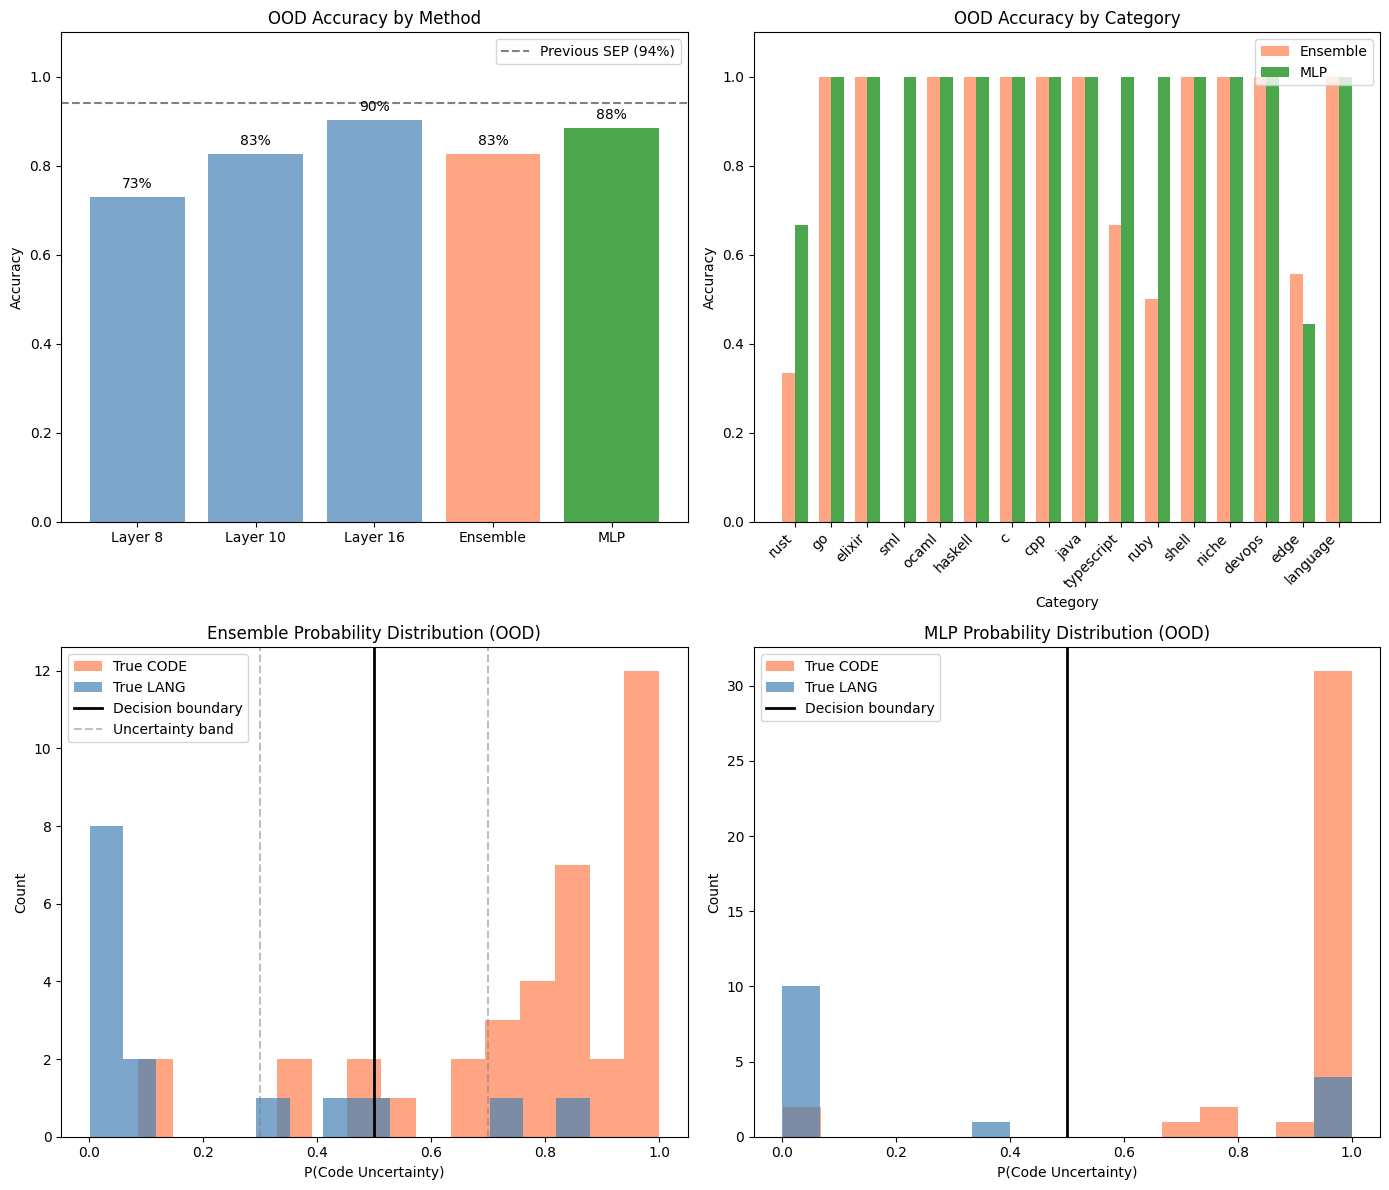

In [17]:
# Cell 17: Visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: OOD Accuracy Comparison
ax1 = axes[0, 0]
methods = list(ood_accuracies.keys())
accs = list(ood_accuracies.values())
colors = ['steelblue'] * len(ENSEMBLE_LAYERS) + ['coral', 'green']
bars = ax1.bar(methods, accs, color=colors, alpha=0.7)
ax1.axhline(y=0.94, color='gray', linestyle='--', label='Previous SEP (94%)')
ax1.set_ylabel('Accuracy')
ax1.set_title('OOD Accuracy by Method')
ax1.set_ylim(0, 1.1)
ax1.legend()
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.0%}', ha='center', fontsize=10)

# Plot 2: Accuracy by Category
ax2 = axes[0, 1]
x = np.arange(len(cat_df))
width = 0.35
ax2.bar(x - width/2, cat_df['ensemble'], width, label='Ensemble', color='coral', alpha=0.7)
ax2.bar(x + width/2, cat_df['mlp'], width, label='MLP', color='green', alpha=0.7)
ax2.set_xlabel('Category')
ax2.set_ylabel('Accuracy')
ax2.set_title('OOD Accuracy by Category')
ax2.set_xticks(x)
ax2.set_xticklabels(cat_df['category'], rotation=45, ha='right')
ax2.legend()
ax2.set_ylim(0, 1.1)

# Plot 3: Ensemble Probability Distribution
ax3 = axes[1, 0]
code_probs = ood_df[ood_df['true_label'] == 1]['prob_ensemble']
lang_probs = ood_df[ood_df['true_label'] == 0]['prob_ensemble']
ax3.hist(code_probs, bins=15, alpha=0.7, label='True CODE', color='coral')
ax3.hist(lang_probs, bins=15, alpha=0.7, label='True LANG', color='steelblue')
ax3.axvline(x=0.5, color='black', linestyle='-', linewidth=2, label='Decision boundary')
ax3.axvline(x=0.3, color='gray', linestyle='--', alpha=0.5)
ax3.axvline(x=0.7, color='gray', linestyle='--', alpha=0.5, label='Uncertainty band')
ax3.set_xlabel('P(Code Uncertainty)')
ax3.set_ylabel('Count')
ax3.set_title('Ensemble Probability Distribution (OOD)')
ax3.legend()

# Plot 4: MLP Probability Distribution
ax4 = axes[1, 1]
code_probs_mlp = ood_df[ood_df['true_label'] == 1]['prob_mlp']
lang_probs_mlp = ood_df[ood_df['true_label'] == 0]['prob_mlp']
ax4.hist(code_probs_mlp, bins=15, alpha=0.7, label='True CODE', color='coral')
ax4.hist(lang_probs_mlp, bins=15, alpha=0.7, label='True LANG', color='steelblue')
ax4.axvline(x=0.5, color='black', linestyle='-', linewidth=2, label='Decision boundary')
ax4.set_xlabel('P(Code Uncertainty)')
ax4.set_ylabel('Count')
ax4.set_title('MLP Probability Distribution (OOD)')
ax4.legend()

plt.tight_layout()
plt.savefig('week3_robust_sep_results.png', dpi=150)
plt.show()

In [18]:
# Cell 18: Statistical Comparison

print("\n" + "="*80)
print("STATISTICAL ANALYSIS")
print("="*80)

# Compare ensemble vs single best layer
best_single_layer = max(ENSEMBLE_LAYERS, key=lambda l: ood_accuracies[f'Layer {l}'])
best_single_acc = ood_accuracies[f'Layer {best_single_layer}']
ensemble_acc = ood_accuracies['Ensemble']
mlp_acc = ood_accuracies['MLP']

print(f"\nBest single layer: Layer {best_single_layer} ({best_single_acc:.1%})")
print(f"Ensemble: {ensemble_acc:.1%}")
print(f"MLP: {mlp_acc:.1%}")

# Improvement over previous SEP
prev_sep_acc = 0.94  # 16/17 from original SEP
print(f"\nImprovement over previous SEP (94%):")
print(f"  Ensemble: {(ensemble_acc - prev_sep_acc)*100:+.1f}%")
print(f"  MLP: {(mlp_acc - prev_sep_acc)*100:+.1f}%")

# Cases where ensemble beats single layers
print(f"\nCases where ensemble > all single layers:")
for _, row in ood_df.iterrows():
    single_correct = all(
        row[f'pred_layer_{l}'] == row['true_label']
        for l in ENSEMBLE_LAYERS
    )
    ens_correct = row['pred_ensemble'] == row['true_label']

    if ens_correct and not single_correct:
        print(f"  ✓ '{row['prompt'][:40]}...' - Ensemble saved!")


STATISTICAL ANALYSIS

Best single layer: Layer 16 (90.4%)
Ensemble: 82.7%
MLP: 88.5%

Improvement over previous SEP (94%):
  Ensemble: -11.3%
  MLP: -5.5%

Cases where ensemble > all single layers:
  ✓ 'func main() {...' - Ensemble saved!
  ✓ 'def handle_call(...' - Ensemble saved!
  ✓ 'let rec fibonacci n =...' - Ensemble saved!
  ✓ 'data Maybe a =...' - Ensemble saved!
  ✓ 'std::vector<...' - Ensemble saved!
  ✓ 'public class Main {...' - Ensemble saved!
  ✓ 'interface User {...' - Ensemble saved!
  ✓ 'TypeError: expected...' - Ensemble saved!


## 5. Save Best Model

In [19]:
# Cell 19: Save Results

# Determine best model
best_method = max(ood_accuracies, key=ood_accuracies.get)
best_acc = ood_accuracies[best_method]

print(f"Best model: {best_method} with {best_acc:.1%} OOD accuracy")

# Save ensemble probe
ensemble_data = {
    'probes': single_probes,
    'scalers': single_scalers,
    'layers': ENSEMBLE_LAYERS,
    'uncertainty_band': (0.3, 0.7),
    'train_accuracy': ensemble_accuracy,
    'ood_accuracy': ensemble_acc,
}

with open('robust_sep_ensemble.pkl', 'wb') as f:
    pickle.dump(ensemble_data, f)

# Save MLP probe
mlp_data = {
    'probe': mlp_probe,
    'scaler': mlp_scaler,
    'layers': ENSEMBLE_LAYERS,
    'hidden_sizes': best_mlp_config['hidden'],
    'train_accuracy': best_mlp_config['accuracy'],
    'ood_accuracy': mlp_acc,
}

with open('robust_sep_mlp.pkl', 'wb') as f:
    pickle.dump(mlp_data, f)

# Save detailed results
ood_df.to_csv('week3_robust_sep_ood_results.csv', index=False)
cat_df.to_csv('week3_robust_sep_category_results.csv', index=False)

print(f"\nSaved:")
print(f"  - robust_sep_ensemble.pkl")
print(f"  - robust_sep_mlp.pkl")
print(f"  - week3_robust_sep_ood_results.csv")
print(f"  - week3_robust_sep_category_results.csv")

Best model: Layer 16 with 90.4% OOD accuracy

Saved:
  - robust_sep_ensemble.pkl
  - robust_sep_mlp.pkl
  - week3_robust_sep_ood_results.csv
  - week3_robust_sep_category_results.csv


## 6. Summary

In [20]:
# Cell 20: Final Summary

print("\n" + "="*80)
print("FINAL SUMMARY: ROBUST SEP PROBE")
print("="*80)

print(f"""
IMPROVEMENTS IMPLEMENTED:
────────────────────────────────────────────────────────────────────────
1. Layer Ensemble: Layers {ENSEMBLE_LAYERS} with confidence weighting
2. MLP Probe: {best_mlp_config['name']} on concatenated hidden states
3. Expanded Training: {len(TRAIN_EXAMPLES)} examples (was 20)
4. Comprehensive OOD: {len(OOD_EXAMPLES)} test examples across {len(cat_df)} categories
5. Uncertainty Band: Three-way classification (code/ambiguous/lang)

RESULTS:
────────────────────────────────────────────────────────────────────────
                        Train Acc    OOD Acc
Previous SEP (Layer 8)  100%         94%
Layer Ensemble          {ensemble_accuracy:.0%}          {ensemble_acc:.0%}
MLP Probe               {best_mlp_config['accuracy']:.0%}          {mlp_acc:.0%}

BEST MODEL: {best_method}
────────────────────────────────────────────────────────────────────────
OOD Accuracy: {best_acc:.0%}
Improvement over previous: {(best_acc - 0.94)*100:+.1f}%

RECOMMENDATION:
────────────────────────────────────────────────────────────────────────
Use {'Ensemble' if ensemble_acc >= mlp_acc else 'MLP'} for production:
- {'Interpretable (see per-layer contributions)' if ensemble_acc >= mlp_acc else 'Slightly better accuracy'}
- {'Robust to individual layer failures' if ensemble_acc >= mlp_acc else 'Captures non-linear patterns'}
- {'No extra training needed' if ensemble_acc >= mlp_acc else 'Single model, simpler deployment'}
""")

print("="*80)


FINAL SUMMARY: ROBUST SEP PROBE

IMPROVEMENTS IMPLEMENTED:
────────────────────────────────────────────────────────────────────────
1. Layer Ensemble: Layers [8, 10, 16] with confidence weighting
2. MLP Probe: MLP-256-128 on concatenated hidden states
3. Expanded Training: 40 examples (was 20)
4. Comprehensive OOD: 52 test examples across 16 categories
5. Uncertainty Band: Three-way classification (code/ambiguous/lang)

RESULTS:
────────────────────────────────────────────────────────────────────────
                        Train Acc    OOD Acc
Previous SEP (Layer 8)  100%         94%
Layer Ensemble          100%          83%
MLP Probe               98%          88%

BEST MODEL: Layer 16
────────────────────────────────────────────────────────────────────────
OOD Accuracy: 90%
Improvement over previous: -3.6%

RECOMMENDATION:
────────────────────────────────────────────────────────────────────────
Use MLP for production:
- Slightly better accuracy
- Captures non-linear patterns
- Sing